# Merged Graph Construction: Commit-File-Function + Issue-PR-Tag

This notebook constructs a unified heterogeneous graph for vulnerability prediction by merging two graph substructures:

1. **Base graph** (from `graph_for_one_commit.ipynb`):
   - Commit → File → Function hierarchy
   - Co-modification edges between functions
   - Node features and edge attributes for structural analysis

2. **Extension graph** (from `graph_for_one_commit_issues_prs_tags.ipynb`):
   - Commit → Issue / PR / Release Tag relations
   - PR → Issue references
   - Temporal chains for issues/PRs/tags
   - Mode-based feature engineering (raw vs. engineered features)

**Key design**: The commit node serves as the shared bridge between both subgraphs.

In [187]:
import pandas as pd
import numpy as np
import torch
import torch_geometric
from torch_geometric.data import HeteroData
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
import ast
import re

print("✓ Imports loaded")
print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")

✓ Imports loaded
PyTorch version: 2.10.0+cpu
PyG version: 2.7.0


## Configuration

Choose the target commit and the feature engineering mode for issue/PR/tag nodes.

**MODE options:**
- `1`: Only raw data (no engineered commit features)
- `2`: Only manually engineered features (single nodes with edge attributes)
- `3`: Hybrid: tags as raw (multiple nodes), issues/PRs as engineered (single nodes)
- `4`: Engineered features + raw release tags only

For this merged graph, **MODE 3** is recommended as a balanced approach.

In [188]:
# Configuration
MODE = 3
target_hash = "a5a51ad3a1200e2e5ef46c140bab717422e41ca2"

# Engineered feature definitions (for MODE 2 and 3)
ENGINEERED_ISSUE_NODE_FEATURES = [
    'issue_age_median', 'issue_close_rate_180d'
]
ENGINEERED_PR_NODE_FEATURES = [
    'pr_age_median', 'pr_merge_or_close_rate_180d'
]
ENGINEERED_TAG_NODE_FEATURES = [
    'time_since_last_tag', 'tags_last_180d'
]
ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES = [
    'issue_open_at_anchor'
]
ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES = [
    'pr_count'
]
ENGINEERED_COMMIT_TO_TAG_EDGE_FEATURES = [
    'has_release_pressure_180d'
]
ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES = [
    'pr_to_issue_open_ratio_90d', 'has_issue_pr_gap'
]
ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES = [
    'activity_since_last_tag'
]

# Exclusion patterns for raw feature extraction
EXCLUDE_PATTERNS = [
    'hash', 'repo', 'url', 'id', 'number', 'node_id', 'fc_hash', 'vcc_hash', 
    'matched_anchor', 'window_since', 'window_until', 'commit_datetime',
    'created_at', 'closed_at', 'merged_at', 'updated_at', 'title', 'body'
]

print(f"✓ Configuration set: MODE={MODE}, target_hash={target_hash[:16]}...")

✓ Configuration set: MODE=3, target_hash=a5a51ad3a1200e2e...


## Data Loading

Load all required data sources for both base and extension graphs.

In [189]:
# Base graph data (commit-file-function)
commit_info = pd.read_csv("../data/commit_info.csv")
file_info = pd.read_csv("../data/file_info_new.csv")
function_info = pd.read_csv("../data/function_info_new.csv")

print("Base graph data loaded:")
print(f"  commit_info: {commit_info.shape}")
print(f"  file_info: {file_info.shape}")
print(f"  function_info: {function_info.shape}")

# Extension graph data (issue-PR-tag)
commit_features = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\derived\preprocessing_final\final_commit_level_features.csv")
issue_info = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\issue_info_v3.csv")
pr_info = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\pull_request_info_v3.csv")
release_tag_info = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\release_tag_info_v3.csv")

print("\nExtension graph data loaded:")
print(f"  commit_features: {commit_features.shape}")
print(f"  issue_info: {issue_info.shape}")
print(f"  pr_info: {pr_info.shape}")
print(f"  release_tag_info: {release_tag_info.shape}")

print(f"\n✓ All data loaded successfully")

Base graph data loaded:
  commit_info: (8796, 21)
  file_info: (10872, 16)
  function_info: (12847, 15)

Extension graph data loaded:
  commit_features: (8773, 16)
  issue_info: (691670, 10)
  pr_info: (469952, 13)
  release_tag_info: (6617, 8)

✓ All data loaded successfully


## Helper Functions

Utility functions adapted from both source notebooks.

In [190]:
def detect_id_column(df, candidates):
    """Detect the best ID column from candidates list."""
    for col in candidates:
        if col in df.columns:
            return col
    print(f"⚠ No ID column found from {candidates}, using index as ID")
    return None

def extract_raw_numeric_features(df, exclude_patterns=EXCLUDE_PATTERNS):
    """Extract numeric features from raw dataframe, excluding identifier-like columns."""
    if df.empty:
        return np.zeros((len(df), 1), dtype="float32"), []
    
    numeric_cols = df.select_dtypes(include=[np.number, bool]).columns.tolist()
    filtered_cols = [
        col for col in numeric_cols 
        if not any(pat in col.lower() for pat in exclude_patterns)
    ]
    
    if not filtered_cols:
        return np.zeros((len(df), 1), dtype="float32"), []
    
    return df[filtered_cols].fillna(0).values.astype("float32"), filtered_cols

def deduplicate_entities(df, id_col):
    """Deduplicate entities by ID column, return unique df and id-to-index mapping."""
    if id_col is None:
        df_unique = df.copy().reset_index(drop=True)
        id_to_idx = {i: i for i in range(len(df_unique))}
    else:
        df_unique = df.drop_duplicates(subset=[id_col]).reset_index(drop=True)
        id_to_idx = {row[id_col]: i for i, row in df_unique.iterrows()}
    return df_unique, id_to_idx

def build_pr_issue_edges(pr_df_unique, pr_id_col, issue_df_unique, issue_id_col):
    """Build PR-Issue edges via direct column match or regex extraction."""
    pr_issue_src, pr_issue_dst = [], []
    issue_id_to_idx = {row[issue_id_col]: i for i, row in issue_df_unique.iterrows()} if issue_id_col else {}
    
    # Strategy A: direct column match
    link_cols = ['issue_id', 'linked_issue_id', 'closing_issue_id', 'issue_number']
    matched_col = None
    for col in link_cols:
        if col in pr_df_unique.columns:
            matched_col = col
            break
    
    if matched_col and issue_id_col:
        for pr_idx, row in pr_df_unique.iterrows():
            issue_id = row[matched_col]
            if pd.notna(issue_id) and issue_id in issue_id_to_idx:
                pr_issue_src.append(pr_idx)
                pr_issue_dst.append(issue_id_to_idx[issue_id])
        if pr_issue_src:
            print(f"✓ Built PR-Issue edges via column '{matched_col}': {len(pr_issue_src)} edges")
            return torch.tensor([pr_issue_src, pr_issue_dst], dtype=torch.long)
    
    # Strategy B: regex extraction from text
    text_cols = [c for c in ['body', 'title'] if c in pr_df_unique.columns]
    if text_cols and issue_id_col and issue_id_col in ['number', 'issue_number']:
        issue_numbers = set(issue_df_unique[issue_id_col].dropna().astype(int))
        for pr_idx, row in pr_df_unique.iterrows():
            text = " ".join([str(row[c]) for c in text_cols if pd.notna(row[c])])
            matches = re.findall(r'#(\d+)', text)
            for m in matches:
                num = int(m)
                if num in issue_numbers and num in issue_id_to_idx:
                    pr_issue_src.append(pr_idx)
                    pr_issue_dst.append(issue_id_to_idx[num])
        if pr_issue_src:
            print(f"✓ Built PR-Issue edges via regex extraction: {len(pr_issue_src)} edges")
            return torch.tensor([pr_issue_src, pr_issue_dst], dtype=torch.long)
    
    print("⚠ Could not build PR-Issue edges (no suitable columns or matches)")
    return torch.zeros((2, 0), dtype=torch.long)

def build_temporal_edges(df, timestamp_candidates):
    """Build temporal chain edges for entities based on timestamp."""
    for ts_col in timestamp_candidates:
        if ts_col in df.columns:
            df_copy = df.copy()
            df_copy['_ts'] = pd.to_datetime(df_copy[ts_col], errors='coerce', utc=True)
            df_valid = df_copy.dropna(subset=['_ts']).sort_values('_ts').reset_index(drop=True)
            if len(df_valid) > 1:
                src = list(range(len(df_valid) - 1))
                dst = list(range(1, len(df_valid)))
                return torch.tensor([src, dst], dtype=torch.long), df_valid.index.tolist()
            break
    return torch.zeros((2, 0), dtype=torch.long), []

print("✓ Helper functions defined")

✓ Helper functions defined


## Base Graph Construction: Commit → File → Function

Build the foundational graph structure using commit, file, and function data.
This logic is adapted from `graph_for_one_commit.ipynb`.

In [191]:
def build_base_commit_file_function_graph(target_hash):
    """
    Build the base heterogeneous graph: commit → file → function.
    Returns HeteroData with commit, file, function nodes and their edges.
    
    Adapted from graph_for_one_commit.ipynb.
    """
    # Filter data for target commit
    commit = commit_info[commit_info["hash"] == target_hash]
    files = file_info[file_info["hash"] == target_hash]
    functions = function_info[function_info["hash"] == target_hash]
    
    if commit.empty:
        raise ValueError(f"Commit {target_hash} not found in commit_info")
    
    print(f"Building base graph for commit {target_hash[:16]}...")
    print(f"  Files: {len(files)}")
    print(f"  Functions: {len(functions)}")
    
    # ── 1. Node feature tensors ──────────────────────────────────────────────────
    
    commit_feat_cols = ["num_lines_deleted", "num_lines_added", "num_lines_changed",
                        "num_files_changed", "dmm_unit_size", "dmm_unit_complexity",
                        "dmm_unit_interfacing"]
    file_feat_cols   = ["num_lines_added", "num_lines_deleted", "num_method_changed",
                        "num_lines_of_code", "complexity", "token_count"]
    func_feat_cols   = ["num_lines_of_code", "complexity", "token_count",
                        "length", "top_nesting_level"]
    
    commit_feats = commit[commit_feat_cols].fillna(0).values.astype("float32")
    file_feats   = files[file_feat_cols].fillna(0).values.astype("float32")
    
    # ── 2. Build local index maps ────────────────────────────────────────────────
    
    files_reset = files.reset_index(drop=True)
    filename_to_file_idx = {row["filename"]: i for i, row in files_reset.iterrows()}
    
    functions_reset = functions.reset_index(drop=True)
    has_functions = len(functions_reset) > 0
    
    if has_functions:
        func_feats = functions_reset[func_feat_cols].fillna(0).values.astype("float32")
    else:
        func_feats = np.zeros((0, len(func_feat_cols)), dtype=np.float32)
    
    # ── 3. Edge index + features: commit → file ─────────────────────────────────
    
    num_files_total = len(files_reset)
    commit_to_file_src = torch.zeros(num_files_total, dtype=torch.long)
    commit_to_file_dst = torch.arange(num_files_total, dtype=torch.long)
    commit_to_file_edge = torch.stack([commit_to_file_src, commit_to_file_dst])
    
    # Change type one-hot (ADD, MODIFY, DELETE, RENAME, COPY, UNKNOWN)
    change_type_categories = ["ADD", "MODIFY", "DELETE", "RENAME", "COPY", "UNKNOWN"]
    change_type_map = {ct: i for i, ct in enumerate(change_type_categories)}
    
    commit_total_lines_added   = commit["num_lines_added"].fillna(0).values[0]
    commit_total_lines_deleted = commit["num_lines_deleted"].fillna(0).values[0]
    total_methods_changed      = files_reset["num_method_changed"].fillna(0).sum()
    
    c2f_edge_feats = []
    for _, frow in files_reset.iterrows():
        ct = frow.get("change_type", "UNKNOWN")
        one_hot = [0.0] * len(change_type_categories)
        idx = change_type_map.get(str(ct).upper(), change_type_map["UNKNOWN"])
        one_hot[idx] = 1.0
    
        lines_added_ratio   = frow["num_lines_added"]   / max(commit_total_lines_added, 1)
        lines_deleted_ratio = frow["num_lines_deleted"]  / max(commit_total_lines_deleted, 1)
        method_change_ratio = frow["num_method_changed"] / max(total_methods_changed, 1)
    
        old_p = str(frow.get("old_path", ""))
        new_p = str(frow.get("new_path", ""))
        path_changed = float(old_p != new_p and old_p != "" and new_p != "")
    
        c2f_edge_feats.append(one_hot + [lines_added_ratio, lines_deleted_ratio,
                                          method_change_ratio, path_changed])
    
    c2f_edge_attr = torch.tensor(c2f_edge_feats, dtype=torch.float32)
    
    # ── 4. Edge index + features: file → function ──────────────────────────────
    
    file_src, func_dst, f2fn_edge_feats = [], [], []
    
    if has_functions:
        for func_idx, frow in functions_reset.iterrows():
            f_idx = filename_to_file_idx.get(frow["filename"])
            if f_idx is None:
                continue  # function's file not in this commit's file list
            file_src.append(f_idx)
            func_dst.append(func_idx)
    
            file_row = files_reset.iloc[f_idx]
            file_loc        = max(file_row["num_lines_of_code"], 1)
            file_complexity  = max(file_row["complexity"], 1)
            file_tokens      = max(file_row["token_count"], 1)
    
            loc_fraction     = frow["length"]       / file_loc
            complexity_ratio = frow["complexity"]    / file_complexity
            token_ratio      = frow["token_count"]  / file_tokens
            position         = frow["start_line"]   / file_loc
    
            try:
                params = ast.literal_eval(frow["parameters"]) if isinstance(frow["parameters"], str) else []
                num_params = float(len(params))
            except:
                num_params = 0.0
    
            bc = frow.get("before_change", "")
            before_change = 0.0
            if isinstance(bc, str) and bc.strip() != "":
                before_change = 1.0
            elif isinstance(bc, (int, float)) and not pd.isna(bc):
                before_change = float(bool(bc))
    
            f2fn_edge_feats.append([loc_fraction, complexity_ratio, token_ratio,
                                   position, num_params, before_change])
    
    if file_src:
        file_to_func_edge = torch.tensor([file_src, func_dst], dtype=torch.long)
        f2fn_edge_attr = torch.tensor(f2fn_edge_feats, dtype=torch.float32)
    else:
        file_to_func_edge = torch.zeros((2, 0), dtype=torch.long)
        f2fn_edge_attr = torch.zeros((0, 6), dtype=torch.float32)
    
    # ── 5. Co-modification edges: function ↔ function ──────────────────────────
    
    co_src, co_dst, co_feats = [], [], []
    
    if has_functions:
        for f_idx, fname in enumerate(files_reset["filename"]):
            func_indices = [i for i, r in functions_reset.iterrows()
                            if r["filename"] == fname]
            if len(func_indices) < 2:
                continue  # need at least 2 functions for co-modification
            for a, b in combinations(func_indices, 2):
                fa, fb = functions_reset.iloc[a], functions_reset.iloc[b]
                file_loc = max(files_reset.iloc[f_idx]["num_lines_of_code"], 1)
                gap = abs(fa["start_line"] - fb["end_line"]) / file_loc
                proximity = 1.0 / (1.0 + gap)
                cplx_sim = 1.0 - abs(fa["complexity"] - fb["complexity"]) / max(fa["complexity"], fb["complexity"], 1)
                for s, d in [(a, b), (b, a)]:
                    co_src.append(s)
                    co_dst.append(d)
                    co_feats.append([proximity, cplx_sim])
    
    if co_src:
        co_mod_edge = torch.tensor([co_src, co_dst], dtype=torch.long)
        co_mod_attr = torch.tensor(co_feats, dtype=torch.float32)
    else:
        co_mod_edge = torch.zeros((2, 0), dtype=torch.long)
        co_mod_attr = torch.zeros((0, 2), dtype=torch.float32)
    
    # ── 6. Assemble base HeteroData ───────────────────────────────────────────────
    
    base_data = HeteroData()
    
    base_data["commit"].x   = torch.tensor(commit_feats)
    base_data["file"].x     = torch.tensor(file_feats)
    base_data["function"].x = torch.tensor(func_feats)
    
    base_data["commit", "has", "file"].edge_index     = commit_to_file_edge
    base_data["commit", "has", "file"].edge_attr      = c2f_edge_attr
    
    base_data["file", "has", "function"].edge_index   = file_to_func_edge
    base_data["file", "has", "function"].edge_attr    = f2fn_edge_attr
    
    base_data["function", "co_modified", "function"].edge_index = co_mod_edge
    base_data["function", "co_modified", "function"].edge_attr  = co_mod_attr
    
    # Store metadata for later inspection
    base_metadata = {
        "commit_feat_cols": commit_feat_cols,
        "file_feat_cols": file_feat_cols,
        "func_feat_cols": func_feat_cols,
        "num_files": num_files_total,
        "num_functions": len(functions_reset),
        "files_with_funcs": len(set(file_src)),
        "files_without_funcs": num_files_total - len(set(file_src))
    }
    
    print(f"✓ Base graph constructed:")
    print(f"    Commit nodes: 1")
    print(f"    File nodes: {num_files_total}")
    print(f"    Function nodes: {len(functions_reset)}")
    print(f"    Commit→File edges: {commit_to_file_edge.shape[1]}")
    print(f"    File→Function edges: {file_to_func_edge.shape[1]}")
    print(f"    Function↔Function edges: {co_mod_edge.shape[1]}")
    
    return base_data, base_metadata

print("✓ Base graph builder function defined")

✓ Base graph builder function defined


## Extension Graph: Issue / PR / Tag Subgraph

Add issue, pull request, and release tag nodes and their relationships.
This logic is adapted from `graph_for_one_commit_issues_prs_tags.ipynb`.

The extension is built on top of the base graph's commit node, creating a unified heterogeneous structure.

**Inter-context relations strategy:**
- **PR → Issue**: Uses existing `build_pr_issue_edges()` logic (column match or regex extraction)
- **Tag → PR / Tag → Issue** (MODE 1): All-to-all connections within commit context (conservative approach when no explicit mapping exists)
- **Tag → PR / Tag → Issue** (MODE 2): Single aggregated edge between single nodes
- **Tag → PR / Tag → Issue** (MODE 3): Multiple tags connect to single aggregated PR/Issue nodes
- All relations include bidirectional (reverse) edges

In [192]:
def add_issue_pr_tag_subgraph(base_data, target_hash, mode):
    """
    Extend the base graph with issue/PR/tag nodes and edges.
    The commit node from base_data is reused as the anchor.
    
    Adapted from graph_for_one_commit_issues_prs_tags.ipynb.
    
    Returns: extended HeteroData, extension metadata
    """
    print(f"\nBuilding extension graph (MODE {mode})...")
    
    # Filter extension data for target commit
    commit_data = commit_features[commit_features["hash"] == target_hash]
    if commit_data.empty:
        raise ValueError(f"Commit {target_hash} not found in commit_features")
    
    linked_issues = issue_info[
        (issue_info["fc_hash"] == target_hash) | (issue_info["vcc_hash"] == target_hash)
    ]
    linked_prs = pr_info[
        (pr_info["fc_hash"] == target_hash) | (pr_info["vcc_hash"] == target_hash)
    ]
    linked_tags = release_tag_info[
        (release_tag_info["fc_hash"] == target_hash) | (release_tag_info["vcc_hash"] == target_hash)
    ]
    
    # Deduplicate entities
    issue_id_col = detect_id_column(linked_issues, ['issue_id', 'id', 'number', 'issue_number'])
    pr_id_col = detect_id_column(linked_prs, ['pull_request_id', 'pr_id', 'id', 'number', 'pull_request_number'])
    tag_id_col = detect_id_column(linked_tags, ['tag_name', 'name', 'tag', 'release_tag', 'id'])
    
    issues_unique, issue_id_to_idx = deduplicate_entities(linked_issues, issue_id_col)
    prs_unique, pr_id_to_idx = deduplicate_entities(linked_prs, pr_id_col)
    tags_unique, tag_id_to_idx = deduplicate_entities(linked_tags, tag_id_col)
    
    num_issues = len(issues_unique)
    num_prs = len(prs_unique)
    num_tags = len(tags_unique)
    
    print(f"  Linked entities: {num_issues} issues, {num_prs} PRs, {num_tags} tags")
    
    # Extract label if available
    y_commit = commit_data["y_binary"].values if "y_binary" in commit_data.columns else np.array([0])
    
    # Build features based on MODE
    feature_info = {"mode": mode, "commit": [], "issue": [], "pull_request": [], "release_tag": []}
    edge_features = {}
    
    if mode == 1:  # Only raw data
        # Commit features from commit_info (already in base graph, skip here)
        X_issue, issue_cols = extract_raw_numeric_features(issues_unique)
        X_pr, pr_cols = extract_raw_numeric_features(prs_unique)
        X_tag, tag_cols = extract_raw_numeric_features(tags_unique)
        feature_info["issue"] = issue_cols
        feature_info["pull_request"] = pr_cols
        feature_info["release_tag"] = tag_cols
        
    elif mode == 2:  # Only engineered - single nodes
        if num_issues > 0:
            issue_features = commit_data[ENGINEERED_ISSUE_NODE_FEATURES].fillna(0).values.astype("float32")
            X_issue = issue_features
        else:
            X_issue = np.zeros((0, len(ENGINEERED_ISSUE_NODE_FEATURES)), dtype="float32")
            
        if num_prs > 0:
            pr_features = commit_data[ENGINEERED_PR_NODE_FEATURES].fillna(0).values.astype("float32")
            X_pr = pr_features
        else:
            X_pr = np.zeros((0, len(ENGINEERED_PR_NODE_FEATURES)), dtype="float32")
            
        if num_tags > 0:
            tag_features = commit_data[ENGINEERED_TAG_NODE_FEATURES].fillna(0).values.astype("float32")
            X_tag = tag_features
        else:
            X_tag = np.zeros((0, len(ENGINEERED_TAG_NODE_FEATURES)), dtype="float32")
        
        feature_info["issue"] = ENGINEERED_ISSUE_NODE_FEATURES
        feature_info["pull_request"] = ENGINEERED_PR_NODE_FEATURES
        feature_info["release_tag"] = ENGINEERED_TAG_NODE_FEATURES
        
        # Store edge features
        edge_features = {
            "commit_to_issue": commit_data[ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES].fillna(0).values.astype("float32") if num_issues > 0 else None,
            "commit_to_pr": commit_data[ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES].fillna(0).values.astype("float32") if num_prs > 0 else None,
            "commit_to_tag": commit_data[ENGINEERED_COMMIT_TO_TAG_EDGE_FEATURES].fillna(0).values.astype("float32") if num_tags > 0 else None,
            "issue_to_pr": commit_data[ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES].fillna(0).values.astype("float32") if num_issues > 0 and num_prs > 0 else None,
            "tag_to_pr": commit_data[ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES].fillna(0).values.astype("float32") if num_tags > 0 and num_prs > 0 else None,
            "tag_to_issue": commit_data[ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES].fillna(0).values.astype("float32") if num_tags > 0 and num_issues > 0 else None,
        }
        feature_info["edge_features"] = {
            "commit_to_issue": ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES,
            "commit_to_pr": ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES,
            "commit_to_tag": ENGINEERED_COMMIT_TO_TAG_EDGE_FEATURES,
            "issue_to_pr": ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES,
            "tag_to_pr": ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES,
            "tag_to_issue": ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES,
        }

    elif mode == 3:  # Hybrid: tags as raw, issues/PRs as engineered
        if num_issues > 0:
            issue_features = commit_data[ENGINEERED_ISSUE_NODE_FEATURES].fillna(0).values.astype("float32")
            X_issue = issue_features
        else:
            X_issue = np.zeros((0, len(ENGINEERED_ISSUE_NODE_FEATURES)), dtype="float32")
        
        if num_prs > 0:
            pr_features = commit_data[ENGINEERED_PR_NODE_FEATURES].fillna(0).values.astype("float32")
            X_pr = pr_features
        else:
            X_pr = np.zeros((0, len(ENGINEERED_PR_NODE_FEATURES)), dtype="float32")
        
        X_tag, tag_cols = extract_raw_numeric_features(tags_unique)
        
        feature_info["issue"] = ENGINEERED_ISSUE_NODE_FEATURES
        feature_info["pull_request"] = ENGINEERED_PR_NODE_FEATURES
        feature_info["release_tag"] = tag_cols
        
        edge_features = {
            "commit_to_issue": commit_data[ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES].fillna(0).values.astype("float32") if num_issues > 0 else None,
            "commit_to_pr": commit_data[ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES].fillna(0).values.astype("float32") if num_prs > 0 else None,
            "issue_to_pr": commit_data[ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES].fillna(0).values.astype("float32") if num_issues > 0 and num_prs > 0 else None,
        }
        feature_info["edge_features"] = {
            "commit_to_issue": ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES,
            "commit_to_pr": ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES,
            "issue_to_pr": ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES,
        }

    else:
        raise ValueError(f"Invalid mode: {mode}")
    
    # Add issue/PR/tag nodes to the base graph
    if num_issues > 0:
        base_data["issue"].x = torch.tensor(X_issue, dtype=torch.float32)
    if num_prs > 0:
        base_data["pull_request"].x = torch.tensor(X_pr, dtype=torch.float32)
    if num_tags > 0:
        base_data["release_tag"].x = torch.tensor(X_tag, dtype=torch.float32)
    
    # Add commit label
    base_data["commit"].y = torch.tensor(y_commit, dtype=torch.long)
    
    # Build commit-entity edges based on MODE
    if mode == 2:  # MODE 2: single nodes, single edges
        if num_issues > 0:
            commit_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["commit", "linked_issue", "issue"].edge_index = commit_issue_edge
            base_data["issue", "issue_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_prs > 0:
            commit_pr_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["commit", "linked_pr", "pull_request"].edge_index = commit_pr_edge
            base_data["pull_request", "pr_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_tags > 0:
            commit_tag_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["commit", "has_release_tag", "release_tag"].edge_index = commit_tag_edge
            base_data["release_tag", "tag_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_prs > 0 and num_issues > 0:
            pr_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["pull_request", "references_issue", "issue"].edge_index = pr_issue_edge
            base_data["issue", "referenced_by_pr", "pull_request"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_tags > 0 and num_prs > 0:
            tag_pr_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["release_tag", "affects_pr", "pull_request"].edge_index = tag_pr_edge
            base_data["pull_request", "in_release", "release_tag"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_tags > 0 and num_issues > 0:
            tag_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["release_tag", "affects_issue", "issue"].edge_index = tag_issue_edge
            base_data["issue", "in_release", "release_tag"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
    
    elif mode == 3:  # MODE 3: issues/PRs as single nodes, tags as multiple nodes
        if num_issues > 0:
            commit_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["commit", "linked_issue", "issue"].edge_index = commit_issue_edge
            base_data["issue", "issue_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_prs > 0:
            commit_pr_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["commit", "linked_pr", "pull_request"].edge_index = commit_pr_edge
            base_data["pull_request", "pr_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_tags > 0:
            commit_tag_edge = torch.stack([
                torch.zeros(num_tags, dtype=torch.long),
                torch.arange(num_tags, dtype=torch.long)
            ])
            base_data["commit", "has_release_tag", "release_tag"].edge_index = commit_tag_edge
            base_data["release_tag", "tag_of", "commit"].edge_index = torch.stack([commit_tag_edge[1], commit_tag_edge[0]])
        
        if num_prs > 0 and num_issues > 0:
            pr_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)
            base_data["pull_request", "references_issue", "issue"].edge_index = pr_issue_edge
            base_data["issue", "referenced_by_pr", "pull_request"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_tags > 0 and num_prs > 0:
            tag_pr_edge = torch.stack([
                torch.arange(num_tags, dtype=torch.long),
                torch.zeros(num_tags, dtype=torch.long)
            ])
            base_data["release_tag", "affects_pr", "pull_request"].edge_index = tag_pr_edge
            base_data["pull_request", "in_release", "release_tag"].edge_index = torch.stack([tag_pr_edge[1], tag_pr_edge[0]])
        
        if num_tags > 0 and num_issues > 0:
            tag_issue_edge = torch.stack([
                torch.arange(num_tags, dtype=torch.long),
                torch.zeros(num_tags, dtype=torch.long)
            ])
            base_data["release_tag", "affects_issue", "issue"].edge_index = tag_issue_edge
            base_data["issue", "in_release", "release_tag"].edge_index = torch.stack([tag_issue_edge[1], tag_issue_edge[0]])
    
    else:  # MODE 1: all multiple nodes
        if num_issues > 0:
            commit_issue_edge = torch.stack([
                torch.zeros(num_issues, dtype=torch.long),
                torch.arange(num_issues, dtype=torch.long)
            ])
            base_data["commit", "linked_issue", "issue"].edge_index = commit_issue_edge
            base_data["issue", "issue_of", "commit"].edge_index = torch.stack([commit_issue_edge[1], commit_issue_edge[0]])
        
        if num_prs > 0:
            commit_pr_edge = torch.stack([
                torch.zeros(num_prs, dtype=torch.long),
                torch.arange(num_prs, dtype=torch.long)
            ])
            base_data["commit", "linked_pr", "pull_request"].edge_index = commit_pr_edge
            base_data["pull_request", "pr_of", "commit"].edge_index = torch.stack([commit_pr_edge[1], commit_pr_edge[0]])
        
        if num_tags > 0:
            commit_tag_edge = torch.stack([
                torch.zeros(num_tags, dtype=torch.long),
                torch.arange(num_tags, dtype=torch.long)
            ])
            base_data["commit", "has_release_tag", "release_tag"].edge_index = commit_tag_edge
            base_data["release_tag", "tag_of", "commit"].edge_index = torch.stack([commit_tag_edge[1], commit_tag_edge[0]])
        
        # Inter-context edges: PR -> Issue
        if num_prs > 0 and num_issues > 0:
            pr_issue_edge = build_pr_issue_edges(prs_unique, pr_id_col, issues_unique, issue_id_col)
            if pr_issue_edge.shape[1] > 0:
                base_data["pull_request", "references_issue", "issue"].edge_index = pr_issue_edge
                base_data["issue", "referenced_by_pr", "pull_request"].edge_index = torch.stack([pr_issue_edge[1], pr_issue_edge[0]])
        
        # Inter-context edges: Tag -> PR (all-to-all within commit context)
        if num_tags > 0 and num_prs > 0:
            # Simple strategy: connect all tags to all PRs within this commit
            tag_pr_src, tag_pr_dst = [], []
            for t_idx in range(num_tags):
                for p_idx in range(num_prs):
                    tag_pr_src.append(t_idx)
                    tag_pr_dst.append(p_idx)
            if tag_pr_src:
                tag_pr_edge = torch.tensor([tag_pr_src, tag_pr_dst], dtype=torch.long)
                base_data["release_tag", "affects_pr", "pull_request"].edge_index = tag_pr_edge
                base_data["pull_request", "in_release", "release_tag"].edge_index = torch.stack([tag_pr_edge[1], tag_pr_edge[0]])
        
        # Inter-context edges: Tag -> Issue (all-to-all within commit context)
        if num_tags > 0 and num_issues > 0:
            # Simple strategy: connect all tags to all issues within this commit
            tag_issue_src, tag_issue_dst = [], []
            for t_idx in range(num_tags):
                for i_idx in range(num_issues):
                    tag_issue_src.append(t_idx)
                    tag_issue_dst.append(i_idx)
            if tag_issue_src:
                tag_issue_edge = torch.tensor([tag_issue_src, tag_issue_dst], dtype=torch.long)
                base_data["release_tag", "affects_issue", "issue"].edge_index = tag_issue_edge
                base_data["issue", "in_release", "release_tag"].edge_index = torch.stack([tag_issue_edge[1], tag_issue_edge[0]])
    
    # Attach edge features for MODE 2 and 3
    if mode == 2 and edge_features:
        if num_issues > 0 and "commit_to_issue" in edge_features and edge_features["commit_to_issue"] is not None:
            base_data["commit", "linked_issue", "issue"].edge_attr = torch.tensor(edge_features["commit_to_issue"], dtype=torch.float32)
            base_data["issue", "issue_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_issue"], dtype=torch.float32)
        
        if num_prs > 0 and "commit_to_pr" in edge_features and edge_features["commit_to_pr"] is not None:
            base_data["commit", "linked_pr", "pull_request"].edge_attr = torch.tensor(edge_features["commit_to_pr"], dtype=torch.float32)
            base_data["pull_request", "pr_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_pr"], dtype=torch.float32)
        
        if num_tags > 0 and "commit_to_tag" in edge_features and edge_features["commit_to_tag"] is not None:
            base_data["commit", "has_release_tag", "release_tag"].edge_attr = torch.tensor(edge_features["commit_to_tag"], dtype=torch.float32)
            base_data["release_tag", "tag_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_tag"], dtype=torch.float32)
        
        if num_prs > 0 and num_issues > 0 and "issue_to_pr" in edge_features and edge_features["issue_to_pr"] is not None:
            base_data["pull_request", "references_issue", "issue"].edge_attr = torch.tensor(edge_features["issue_to_pr"], dtype=torch.float32)
            base_data["issue", "referenced_by_pr", "pull_request"].edge_attr = torch.tensor(edge_features["issue_to_pr"], dtype=torch.float32)
        
        if num_tags > 0 and num_prs > 0 and "tag_to_pr" in edge_features and edge_features["tag_to_pr"] is not None:
            base_data["release_tag", "affects_pr", "pull_request"].edge_attr = torch.tensor(edge_features["tag_to_pr"], dtype=torch.float32)
            base_data["pull_request", "in_release", "release_tag"].edge_attr = torch.tensor(edge_features["tag_to_pr"], dtype=torch.float32)
        
        if num_tags > 0 and num_issues > 0 and "tag_to_issue" in edge_features and edge_features["tag_to_issue"] is not None:
            base_data["release_tag", "affects_issue", "issue"].edge_attr = torch.tensor(edge_features["tag_to_issue"], dtype=torch.float32)
            base_data["issue", "in_release", "release_tag"].edge_attr = torch.tensor(edge_features["tag_to_issue"], dtype=torch.float32)
    
    elif mode == 3 and edge_features:
        if num_issues > 0 and "commit_to_issue" in edge_features and edge_features["commit_to_issue"] is not None:
            base_data["commit", "linked_issue", "issue"].edge_attr = torch.tensor(edge_features["commit_to_issue"], dtype=torch.float32)
            base_data["issue", "issue_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_issue"], dtype=torch.float32)
        
        if num_prs > 0 and "commit_to_pr" in edge_features and edge_features["commit_to_pr"] is not None:
            base_data["commit", "linked_pr", "pull_request"].edge_attr = torch.tensor(edge_features["commit_to_pr"], dtype=torch.float32)
            base_data["pull_request", "pr_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_pr"], dtype=torch.float32)
        
        if num_prs > 0 and num_issues > 0 and "issue_to_pr" in edge_features and edge_features["issue_to_pr"] is not None:
            base_data["pull_request", "references_issue", "issue"].edge_attr = torch.tensor(edge_features["issue_to_pr"], dtype=torch.float32)
            base_data["issue", "referenced_by_pr", "pull_request"].edge_attr = torch.tensor(edge_features["issue_to_pr"], dtype=torch.float32)
    
    # Build temporal edges
    if mode not in [2, 3]:
        if num_issues > 0:
            issue_temp_edge, _ = build_temporal_edges(issues_unique, ['created_at', 'issue_created_at', 'open_at', 'opened_at', 'datetime'])
            if issue_temp_edge.shape[1] > 0:
                base_data["issue", "next_issue", "issue"].edge_index = issue_temp_edge
                base_data["issue", "prev_issue", "issue"].edge_index = torch.stack([issue_temp_edge[1], issue_temp_edge[0]])
        
        if num_prs > 0:
            pr_temp_edge, _ = build_temporal_edges(prs_unique, ['created_at', 'pr_created_at', 'opened_at', 'datetime'])
            if pr_temp_edge.shape[1] > 0:
                base_data["pull_request", "next_pr", "pull_request"].edge_index = pr_temp_edge
                base_data["pull_request", "prev_pr", "pull_request"].edge_index = torch.stack([pr_temp_edge[1], pr_temp_edge[0]])
        
        if num_tags > 0:
            tag_temp_edge, _ = build_temporal_edges(tags_unique, ['tagged_at', 'published_at', 'created_at', 'datetime'])
            if tag_temp_edge.shape[1] > 0:
                base_data["release_tag", "next_tag", "release_tag"].edge_index = tag_temp_edge
                base_data["release_tag", "prev_tag", "release_tag"].edge_index = torch.stack([tag_temp_edge[1], tag_temp_edge[0]])
    
    elif mode == 3:  # MODE 3: only tag temporal edges
        if num_tags > 0:
            tag_temp_edge, _ = build_temporal_edges(tags_unique, ['tagged_at', 'published_at', 'created_at', 'datetime'])
            if tag_temp_edge.shape[1] > 0:
                base_data["release_tag", "next_tag", "release_tag"].edge_index = tag_temp_edge
                base_data["release_tag", "prev_tag", "release_tag"].edge_index = torch.stack([tag_temp_edge[1], tag_temp_edge[0]])
    
    # Build extension metadata
    extension_metadata = {
        "num_issues": num_issues,
        "num_prs": num_prs,
        "num_tags": num_tags,
        "issues_unique": issues_unique,
        "prs_unique": prs_unique,
        "tags_unique": tags_unique,
        "feature_info": feature_info
    }
    
    # Print summary
    print(f"✓ Extension graph added:")
    print(f"    Issue nodes: {num_issues} ({1 if mode in [2,3] and num_issues > 0 else num_issues} in graph)")
    print(f"    PR nodes: {num_prs} ({1 if mode in [2,3] and num_prs > 0 else num_prs} in graph)")
    print(f"    Tag nodes: {num_tags} ({1 if mode == 2 and num_tags > 0 else num_tags} in graph)")
    
    return base_data, extension_metadata

print("✓ Extension graph builder function defined")

✓ Extension graph builder function defined


## Build Merged Graph

Combine base and extension graphs into a single unified heterogeneous graph.

In [193]:
def build_merged_graph_for_one_commit(target_hash, mode):
    """
    Build the complete merged heterogeneous graph for one commit.
    
    Steps:
    1. Build base graph (commit → file → function)
    2. Add extension subgraph (commit → issue/PR/tag)
    3. Return unified HeteroData
    """
    print(f"{'='*70}")
    print(f"Building merged graph for commit: {target_hash[:16]}...")
    print(f"MODE: {mode}")
    print(f"{'='*70}")
    
    # Step 1: Build base graph
    base_data, base_metadata = build_base_commit_file_function_graph(target_hash)
    
    # Step 2: Add extension subgraph
    merged_data, extension_metadata = add_issue_pr_tag_subgraph(base_data, target_hash, mode)
    
    # Combine metadata
    full_metadata = {
        "target_hash": target_hash,
        "mode": mode,
        "base": base_metadata,
        "extension": extension_metadata
    }
    
    print(f"\n{'='*70}")
    print(f"✓ Merged graph construction complete!")
    print(f"{'='*70}")
    
    return merged_data, full_metadata

print("✓ Merged graph builder function defined")

✓ Merged graph builder function defined


In [194]:
# Build the merged graph
merged_graph, metadata = build_merged_graph_for_one_commit(target_hash, MODE)

print("\n" + "="*70)
print("INTER-CONTEXT RELATIONS DEBUG")
print("="*70)
print(f"\nAll edge types in merged graph ({len(merged_graph.edge_types)}):")
for et in merged_graph.edge_types:
    shape = merged_graph[et].edge_index.shape
    print(f"  {et}: {shape}")

print(f"\nTarget inter-context relations:")
target_rels = [
    ("pull_request", "references_issue", "issue"),
    ("issue", "referenced_by_pr", "pull_request"),
    ("release_tag", "affects_pr", "pull_request"),
    ("pull_request", "in_release", "release_tag"),
    ("release_tag", "affects_issue", "issue"),
    ("issue", "in_release", "release_tag")
]
for rel in target_rels:
    if rel in merged_graph.edge_types:
        count = merged_graph[rel].edge_index.shape[1]
        print(f"  ✓ {rel}: {count} edges")
    else:
        print(f"  ✗ {rel}: MISSING")
print("="*70)

Building merged graph for commit: a5a51ad3a1200e2e...
MODE: 3
Building base graph for commit a5a51ad3a1200e2e...
  Files: 2
  Functions: 2
✓ Base graph constructed:
    Commit nodes: 1
    File nodes: 2
    Function nodes: 2
    Commit→File edges: 2
    File→Function edges: 2
    Function↔Function edges: 0

Building extension graph (MODE 3)...
  Linked entities: 2068 issues, 1107 PRs, 7 tags
✓ Extension graph added:
    Issue nodes: 2068 (1 in graph)
    PR nodes: 1107 (1 in graph)
    Tag nodes: 7 (7 in graph)

✓ Merged graph construction complete!

INTER-CONTEXT RELATIONS DEBUG

All edge types in merged graph (17):
  ('commit', 'has', 'file'): torch.Size([2, 2])
  ('file', 'has', 'function'): torch.Size([2, 2])
  ('function', 'co_modified', 'function'): torch.Size([2, 0])
  ('commit', 'linked_issue', 'issue'): torch.Size([2, 1])
  ('issue', 'issue_of', 'commit'): torch.Size([2, 1])
  ('commit', 'linked_pr', 'pull_request'): torch.Size([2, 1])
  ('pull_request', 'pr_of', 'commit'): to

## Graph Inspection and Validation

Examine the structure, features, and properties of the merged graph.

In [195]:
def validate_merged_graph(data, metadata):
    """Validate and inspect the merged graph structure."""
    print(f"\n{'='*70}")
    print(f"MERGED GRAPH STRUCTURE VALIDATION")
    print(f"{'='*70}")
    
    # Basic structure
    print(f"\n--- HeteroData Summary ---")
    print(data)
    
    # Node counts per type
    print(f"\n--- Node Counts ---")
    node_types = data.node_types
    for ntype in node_types:
        if hasattr(data[ntype], 'x'):
            print(f"  {ntype}: {data[ntype].x.shape[0]} nodes, {data[ntype].x.shape[1]} features")
        else:
            print(f"  {ntype}: present but no features")
    
    # Edge counts per relation
    print(f"\n--- Edge Counts ---")
    total_edges = 0
    for edge_type in data.edge_types:
        num_edges = data[edge_type].edge_index.shape[1]
        total_edges += num_edges
        has_attr = hasattr(data[edge_type], 'edge_attr') and data[edge_type].edge_attr is not None
        if has_attr:
            attr_shape = data[edge_type].edge_attr.shape
            print(f"  {edge_type}: {num_edges} edges (edge_attr: {attr_shape})")
        else:
            print(f"  {edge_type}: {num_edges} edges")
    print(f"  TOTAL: {total_edges} edges across all relations")
    
    # Feature dimensions from base graph
    print(f"\n--- Base Graph Features (Commit-File-Function) ---")
    base_meta = metadata["base"]
    print(f"  Commit features ({len(base_meta['commit_feat_cols'])}): {base_meta['commit_feat_cols']}")
    print(f"  File features ({len(base_meta['file_feat_cols'])}): {base_meta['file_feat_cols']}")
    print(f"  Function features ({len(base_meta['func_feat_cols'])}): {base_meta['func_feat_cols']}")
    
    # Feature dimensions from extension graph
    print(f"\n--- Extension Graph Features (Issue-PR-Tag) ---")
    ext_meta = metadata["extension"]
    feature_info = ext_meta["feature_info"]
    for ntype in ["issue", "pull_request", "release_tag"]:
        if ntype in node_types and feature_info[ntype]:
            cols = feature_info[ntype]
            print(f"  {ntype} features ({len(cols)}): {cols[:5]}{'...' if len(cols) > 5 else ''}")
    
    # Edge feature info
    if "edge_features" in feature_info:
        print(f"\n--- Edge Features (MODE {metadata['mode']}) ---")
        for edge_type, cols in feature_info["edge_features"].items():
            if cols:
                print(f"  {edge_type}: {cols}")
    
    # Label
    if hasattr(data["commit"], 'y'):
        print(f"\n--- Commit Label ---")
        print(f"  y_binary: {data['commit'].y[0].item()}")
    
    # Graph statistics
    print(f"\n--- Graph Statistics ---")
    print(f"  Node types: {len(node_types)}")
    print(f"  Edge types: {len(data.edge_types)}")
    print(f"  Total nodes: {sum([data[nt].x.shape[0] for nt in node_types if hasattr(data[nt], 'x')])}")
    print(f"  Total edges: {total_edges}")
    
    # Sanity checks
    print(f"\n--- Sanity Checks ---")
    assert data["commit"].x.shape[0] == 1, "Expected exactly 1 commit node"
    print(f"  ✓ Commit node count: 1")
    
    # Check that base graph edges are present
    assert ("commit", "has", "file") in data.edge_types, "Missing commit→file edges"
    print(f"  ✓ Base graph edges present")
    
    # Check node/edge consistency
    for edge_type in data.edge_types:
        src_type, rel, dst_type = edge_type
        edge_index = data[edge_type].edge_index
        max_src = edge_index[0].max().item() if edge_index.shape[1] > 0 else -1
        max_dst = edge_index[1].max().item() if edge_index.shape[1] > 0 else -1
        
        if max_src >= 0:
            assert max_src < data[src_type].x.shape[0], f"Invalid src index in {edge_type}"
        if max_dst >= 0:
            assert max_dst < data[dst_type].x.shape[0], f"Invalid dst index in {edge_type}"
    print(f"  ✓ All edge indices within valid node ranges")
    
    # Check edge attributes match edge counts
    for edge_type in data.edge_types:
        if hasattr(data[edge_type], 'edge_attr') and data[edge_type].edge_attr is not None:
            num_edges = data[edge_type].edge_index.shape[1]
            num_attrs = data[edge_type].edge_attr.shape[0]
            assert num_edges == num_attrs, f"Edge count mismatch in {edge_type}: {num_edges} edges, {num_attrs} attrs"
    print(f"  ✓ Edge attributes match edge counts")
    
    # Check inter-context relations
    print(f"\n--- Inter-Context Relations Check ---")
    target_relations = [
        ("pull_request", "references_issue", "issue"),
        ("issue", "referenced_by_pr", "pull_request"),
        ("release_tag", "affects_pr", "pull_request"),
        ("pull_request", "in_release", "release_tag"),
        ("release_tag", "affects_issue", "issue"),
        ("issue", "in_release", "release_tag")
    ]
    for rel in target_relations:
        if rel in data.edge_types:
            count = data[rel].edge_index.shape[1]
            print(f"  ✓ {rel}: {count} edges")
        else:
            print(f"  ✗ {rel}: NOT PRESENT")
    
    print(f"\n{'='*70}")
    print(f"✓ Validation complete — Graph is structurally sound")
    print(f"{'='*70}")

# Run validation
validate_merged_graph(merged_graph, metadata)


MERGED GRAPH STRUCTURE VALIDATION

--- HeteroData Summary ---
HeteroData(
  commit={
    x=[1, 7],
    y=[1],
  },
  file={ x=[2, 6] },
  function={ x=[2, 5] },
  issue={ x=[1, 2] },
  pull_request={ x=[1, 2] },
  release_tag={ x=[7, 1] },
  (commit, has, file)={
    edge_index=[2, 2],
    edge_attr=[2, 10],
  },
  (file, has, function)={
    edge_index=[2, 2],
    edge_attr=[2, 6],
  },
  (function, co_modified, function)={
    edge_index=[2, 0],
    edge_attr=[0, 2],
  },
  (commit, linked_issue, issue)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (issue, issue_of, commit)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (commit, linked_pr, pull_request)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (pull_request, pr_of, commit)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (commit, has_release_tag, release_tag)={ edge_index=[2, 7] },
  (release_tag, tag_of, commit)={ edge_index=[2, 7] },
  (pull_request, references_issue, issue)={
    edge_index=[2, 1]

## Visualization

Visualize the merged graph structure using NetworkX.

For large graphs, we sample nodes for visualization while preserving the full graph structure.


GRAPH VISUALIZATION (MODE 3)

Full graph statistics:
  Commit: 1
  Files: 2
  Functions: 2
  Issues: 2068 (1 nodes)
  PRs: 1107 (1 nodes)
  Tags: 7 (7 nodes)


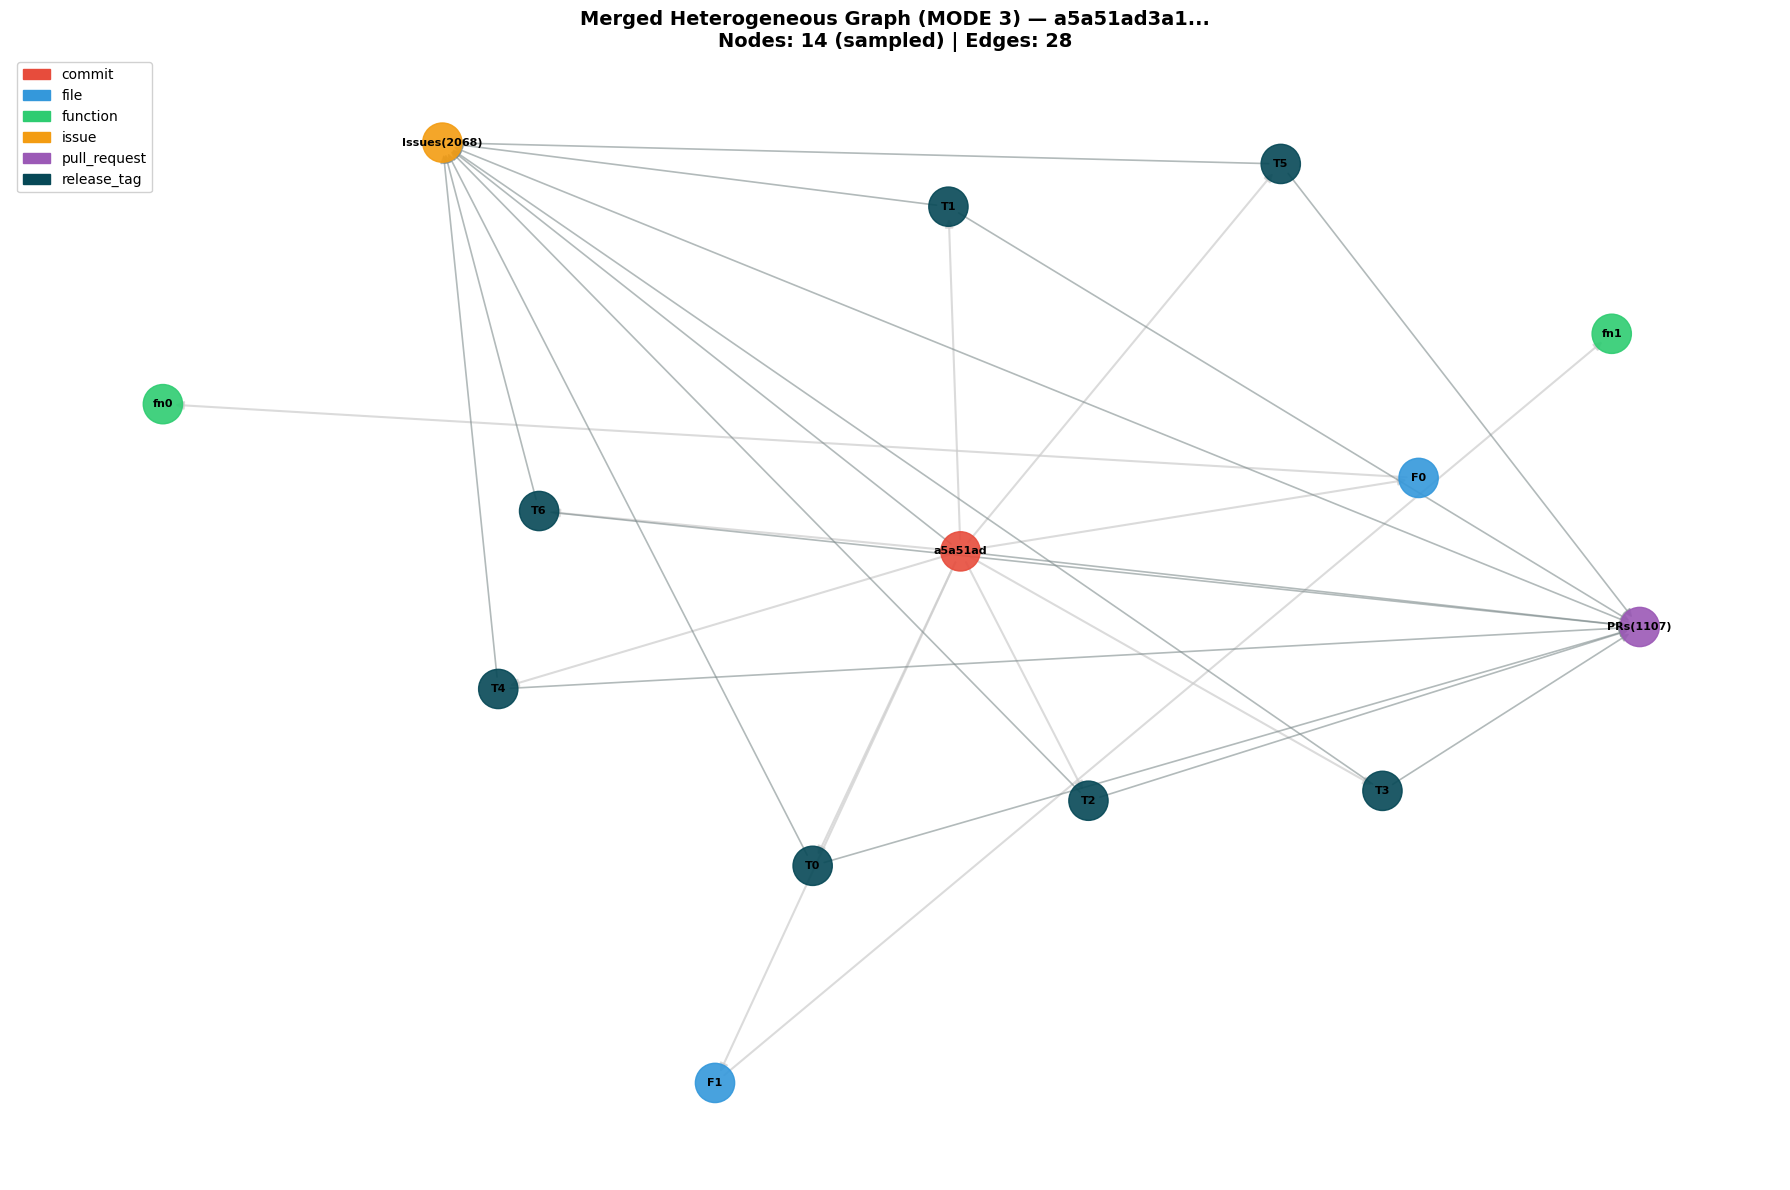


✓ Visualized 14 nodes and 28 edges (sampled)


In [199]:
def visualize_merged_graph(data, metadata, max_display_per_type=10):
    """
    Visualize the merged heterogeneous graph using NetworkX.
    Samples nodes for display if graph is large.
    """
    mode = metadata["mode"]
    target_hash = metadata["target_hash"]
    ext_meta = metadata["extension"]
    
    num_issues = ext_meta["num_issues"]
    num_prs = ext_meta["num_prs"]
    num_tags = ext_meta["num_tags"]
    num_files = metadata["base"]["num_files"]
    num_functions = metadata["base"]["num_functions"]
    
    print(f"\n{'='*70}")
    print(f"GRAPH VISUALIZATION (MODE {mode})")
    print(f"{'='*70}")
    print(f"\nFull graph statistics:")
    print(f"  Commit: 1")
    print(f"  Files: {num_files}")
    print(f"  Functions: {num_functions}")
    print(f"  Issues: {num_issues} ({1 if mode in [2,3] and num_issues > 0 else num_issues} nodes)")
    print(f"  PRs: {num_prs} ({1 if mode in [2,3] and num_prs > 0 else num_prs} nodes)")
    print(f"  Tags: {num_tags} ({1 if mode == 2 and num_tags > 0 else num_tags} nodes)")
    
    # Build NetworkX graph for visualization
    G = nx.DiGraph()
    
    # Add commit node
    G.add_node("commit_0", node_type="commit", label=target_hash[:7])
    
    # Add file nodes (sample if too many)
    file_indices = list(range(min(num_files, max_display_per_type)))
    for i in file_indices:
        G.add_node(f"file_{i}", node_type="file", label=f"F{i}")
    
    # Add function nodes (sample if too many)
    func_indices = list(range(min(num_functions, max_display_per_type)))
    for i in func_indices:
        G.add_node(f"func_{i}", node_type="function", label=f"fn{i}")
    
    # Add issue/PR/tag nodes based on MODE
    if mode == 2:  # Single aggregated nodes
        if num_issues > 0:
            G.add_node("issue_0", node_type="issue", label=f"Issues({num_issues})")
        if num_prs > 0:
            G.add_node("pr_0", node_type="pull_request", label=f"PRs({num_prs})")
        if num_tags > 0:
            G.add_node("tag_0", node_type="release_tag", label=f"Tags({num_tags})")
    elif mode == 3:  # Hybrid
        if num_issues > 0:
            G.add_node("issue_0", node_type="issue", label=f"Issues({num_issues})")
        if num_prs > 0:
            G.add_node("pr_0", node_type="pull_request", label=f"PRs({num_prs})")
        for i in range(min(num_tags, max_display_per_type)):
            G.add_node(f"tag_{i}", node_type="release_tag", label=f"T{i}")
    else:  # MODE 1: multiple nodes
        for i in range(min(num_issues, max_display_per_type)):
            G.add_node(f"issue_{i}", node_type="issue", label=f"I{i}")
        for i in range(min(num_prs, max_display_per_type)):
            G.add_node(f"pr_{i}", node_type="pull_request", label=f"PR{i}")
        for i in range(min(num_tags, max_display_per_type)):
            G.add_node(f"tag_{i}", node_type="release_tag", label=f"T{i}")
    
    # Add edges: commit → file
    if ("commit", "has", "file") in data.edge_types:
        src, dst = data["commit", "has", "file"].edge_index
        for s, d in zip(src.tolist(), dst.tolist()):
            if d < max_display_per_type:
                G.add_edge(f"commit_{s}", f"file_{d}", edge_type="has_file")
    
    # Add edges: file → function
    if ("file", "has", "function") in data.edge_types:
        src, dst = data["file", "has", "function"].edge_index
        for s, d in zip(src.tolist(), dst.tolist()):
            if s < max_display_per_type and d < max_display_per_type:
                G.add_edge(f"file_{s}", f"func_{d}", edge_type="has_func")
    
    # Add edges: function ↔ function (co-modification)
    if ("function", "co_modified", "function") in data.edge_types:
        src, dst = data["function", "co_modified", "function"].edge_index
        added_comod = set()
        for s, d in zip(src.tolist(), dst.tolist()):
            if s < max_display_per_type and d < max_display_per_type:
                edge_key = tuple(sorted([s, d]))
                if edge_key not in added_comod:
                    G.add_edge(f"func_{s}", f"func_{d}", edge_type="co_modified")
                    added_comod.add(edge_key)
    
    # Add edges: commit → issue/PR/tag
    if ("commit", "linked_issue", "issue") in data.edge_types:
        src, dst = data["commit", "linked_issue", "issue"].edge_index
        for s, d in zip(src.tolist(), dst.tolist()):
            if mode in [2, 3] or d < max_display_per_type:
                G.add_edge(f"commit_{s}", f"issue_{d}", edge_type="linked_issue")
    
    if ("commit", "linked_pr", "pull_request") in data.edge_types:
        src, dst = data["commit", "linked_pr", "pull_request"].edge_index
        for s, d in zip(src.tolist(), dst.tolist()):
            if mode in [2, 3] or d < max_display_per_type:
                G.add_edge(f"commit_{s}", f"pr_{d}", edge_type="linked_pr")
    
    if ("commit", "has_release_tag", "release_tag") in data.edge_types:
        src, dst = data["commit", "has_release_tag", "release_tag"].edge_index
        for s, d in zip(src.tolist(), dst.tolist()):
            if mode == 2 or d < max_display_per_type:
                G.add_edge(f"commit_{s}", f"tag_{d}", edge_type="has_tag")
    
    # Add edges: PR → Issue
    if ("pull_request", "references_issue", "issue") in data.edge_types:
        src, dst = data["pull_request", "references_issue", "issue"].edge_index
        for s, d in zip(src.tolist(), dst.tolist()):
            if (mode in [2, 3] or (s < max_display_per_type and d < max_display_per_type)):
                G.add_edge(f"pr_{s}", f"issue_{d}", edge_type="ref_issue")
    
    # Add edges: Tag → PR
    if ("release_tag", "affects_pr", "pull_request") in data.edge_types:
        src, dst = data["release_tag", "affects_pr", "pull_request"].edge_index
        for s, d in zip(src.tolist(), dst.tolist()):
            if s < max_display_per_type and (mode in [2, 3] or d < max_display_per_type):
                G.add_edge(f"tag_{s}", f"pr_{d}", edge_type="tag_affects_pr")
    
    # Add edges: Tag → Issue
    if ("release_tag", "affects_issue", "issue") in data.edge_types:
        src, dst = data["release_tag", "affects_issue", "issue"].edge_index
        for s, d in zip(src.tolist(), dst.tolist()):
            if s < max_display_per_type and (mode in [2, 3] or d < max_display_per_type):
                G.add_edge(f"tag_{s}", f"issue_{d}", edge_type="tag_affects_issue")
    
    # Layout and colors
    color_map = {
        "commit": "#e74c3c",
        "file": "#3498db",
        "function": "#2ecc71",
        "issue": "#f39c12",
        "pull_request": "#9b59b6",
        "release_tag": "#064856"
    }
    
    node_colors = [color_map.get(G.nodes[n]["node_type"], "#95a5a6") for n in G.nodes]
    node_labels = {n: G.nodes[n]["label"] for n in G.nodes}
    
    # Use hierarchical layout if possible
    try:
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
    except:
        pos = nx.random_layout(G, seed=42)
    
    # Plot
    plt.figure(figsize=(18, 12))
    
    # Separate edge types for styling
    hierarchical_edges = [(u, v) for u, v, d in G.edges(data=True) 
                          if d.get("edge_type", "").startswith("has")]
    co_mod_edges = [(u, v) for u, v, d in G.edges(data=True) 
                    if d.get("edge_type") == "co_modified"]
    other_edges = [(u, v) for u, v, d in G.edges(data=True) 
                   if not d.get("edge_type", "").startswith("has") and d.get("edge_type") != "co_modified"]
    
    # Draw edges
    if hierarchical_edges:
        nx.draw_networkx_edges(G, pos, edgelist=hierarchical_edges, edge_color="#cccccc",
                               arrows=True, arrowsize=12, width=1.5, alpha=0.7)
    if co_mod_edges:
        nx.draw_networkx_edges(G, pos, edgelist=co_mod_edges, edge_color="#e74c3c",
                               arrows=False, width=1.0, style="dashed", alpha=0.5)
    if other_edges:
        nx.draw_networkx_edges(G, pos, edgelist=other_edges, edge_color="#7f8c8d",
                               arrows=True, arrowsize=12, width=1.2, alpha=0.6)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, alpha=0.9)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_weight="bold")
    
    # Legend
    legend_handles = [
        mpatches.Patch(color=v, label=k) for k, v in color_map.items()
    ]
    plt.legend(handles=legend_handles, loc="upper left", fontsize=10, framealpha=0.9)
    
    plt.title(f"Merged Heterogeneous Graph (MODE {mode}) — {target_hash[:10]}...\n"
              f"Nodes: {G.number_of_nodes()} (sampled) | Edges: {G.number_of_edges()}",
              fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Visualized {G.number_of_nodes()} nodes and {G.number_of_edges()} edges (sampled)")
    if num_files > max_display_per_type or num_functions > max_display_per_type:
        print(f"  (Full graph has more nodes; visualization is sampled for clarity)")

# Visualize the merged graph
visualize_merged_graph(merged_graph, metadata, max_display_per_type=100)

## Summary and Export

Summary of the merged graph construction and notes on usage.

In [200]:
print(f"\n{'='*70}")
print(f"MERGED GRAPH CONSTRUCTION SUMMARY")
print(f"{'='*70}")
print(f"\nTarget commit: {target_hash[:16]}...")
print(f"Mode: {MODE}")
print(f"\n--- Graph Structure ---")
print(f"Node types: {len(merged_graph.node_types)}")
print(f"  {', '.join(merged_graph.node_types)}")
print(f"\nEdge types: {len(merged_graph.edge_types)}")
for et in merged_graph.edge_types:
    print(f"  {et}")

print(f"\n--- Design Notes ---")
print("""
This merged graph combines two complementary substructures:

1. **Base graph (commit-file-function)**:
   - Captures the structural hierarchy of code changes
   - Includes co-modification patterns between functions
   - Node and edge features from PyDriller metrics

2. **Extension graph (issue-PR-tag)**:
   - Captures project management and release context
   - Links commits to issues, pull requests, and release tags
   - Supports multiple feature engineering modes

The commit node serves as the bridge between both subgraphs, enabling
holistic vulnerability prediction that considers both code structure and
development process context.
""")

print(f"{'='*70}")
print(f"✓ Graph construction complete and validated")
print(f"{'='*70}")


MERGED GRAPH CONSTRUCTION SUMMARY

Target commit: a5a51ad3a1200e2e...
Mode: 3

--- Graph Structure ---
Node types: 6
  commit, file, function, issue, pull_request, release_tag

Edge types: 17
  ('commit', 'has', 'file')
  ('file', 'has', 'function')
  ('function', 'co_modified', 'function')
  ('commit', 'linked_issue', 'issue')
  ('issue', 'issue_of', 'commit')
  ('commit', 'linked_pr', 'pull_request')
  ('pull_request', 'pr_of', 'commit')
  ('commit', 'has_release_tag', 'release_tag')
  ('release_tag', 'tag_of', 'commit')
  ('pull_request', 'references_issue', 'issue')
  ('issue', 'referenced_by_pr', 'pull_request')
  ('release_tag', 'affects_pr', 'pull_request')
  ('pull_request', 'in_release', 'release_tag')
  ('release_tag', 'affects_issue', 'issue')
  ('issue', 'in_release', 'release_tag')
  ('release_tag', 'next_tag', 'release_tag')
  ('release_tag', 'prev_tag', 'release_tag')

--- Design Notes ---

This merged graph combines two complementary substructures:

1. **Base graph (co

## Usage Example: Build Graph for Different Commit

To build a graph for a different commit, simply call the main builder function:

```python
# Example: build graph for another commit
another_hash = "your_commit_hash_here"
graph, meta = build_merged_graph_for_one_commit(another_hash, mode=3)
```

The notebook can be extended to process multiple commits in batch or integrated
into a graph dataset creation pipeline.

In [201]:
# Placeholder for additional experiments or custom analysis
